In [8]:
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate, GridSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, accuracy_score, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = pd.read_csv("../data/student_dropout_dataset.csv")

df["enroll_date"] = pd.to_datetime(df["enroll_date"])
df["days_since_enroll"] = (pd.Timestamp.now() - df["enroll_date"]).dt.days

drop_cols = ["student_id", "enroll_date", "label", "label_name", "label_multiclass"]
X = df.drop(columns=drop_cols)
y = df["label_multiclass"]

print("Features:", X.columns.tolist())
print("X shape:", X.shape)
print("y distribution:\n", y.value_counts().sort_index())

Features: ['age', 'region', 'exam_season', 'courses_enrolled', 'completed_assignments', 'completion_rate', 'login_frequency', 'last_activity_days_ago', 'forum_posts_count', 'dropout_score', 'days_since_enroll']
X shape: (5000, 11)
y distribution:
 label_multiclass
0    1704
1    1663
2    1633
Name: count, dtype: int64


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("Train distribution:\n", y_train.value_counts().sort_index())
print("Test distribution:\n", y_test.value_counts().sort_index())

Train: (4000, 11), Test: (1000, 11)
Train distribution:
 label_multiclass
0    1363
1    1330
2    1307
Name: count, dtype: int64
Test distribution:
 label_multiclass
0    341
1    333
2    326
Name: count, dtype: int64


In [16]:
num_features = ["age", "courses_enrolled", "completed_assignments",
                "completion_rate", "login_frequency",
                "last_activity_days_ago", "forum_posts_count",
                "dropout_score", "days_since_enroll"]
cat_features = ["region"]
bin_features = ["exam_season"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features),
    ("bin", "passthrough", bin_features),
])

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42, n_jobs=-1))
])


In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    rf_pipeline, X_train, y_train,
    cv=cv,
    scoring=["accuracy", "f1_macro"],
    return_train_score=True
)

print("=== Random Forest Baseline (5-Fold CV) ===")
print(f"CV Accuracy : {cv_results['test_accuracy'].mean():.4f} "
      f"(+/- {cv_results['test_accuracy'].std():.4f})")
print(f"CV F1 Macro : {cv_results['test_f1_macro'].mean():.4f} "
      f"(+/- {cv_results['test_f1_macro'].std():.4f})")

=== Random Forest Baseline (5-Fold CV) ===
CV Accuracy : 0.9992 (+/- 0.0010)
CV F1 Macro : 0.9993 (+/- 0.0010)


In [18]:
param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5],
    "classifier__max_features": ["sqrt", "log2"],
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="f1_macro",       # <- optimize ด้วย macro F1
    n_jobs=-1,
    verbose=1,
    refit=True                # <- refit ด้วย best params บน X_train ทั้งหมด
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print(f"Best CV F1 Macro: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Best CV F1 Macro: 0.9995


=== Test Set Performance ===
Accuracy : 0.9980
F1 Macro : 0.9980

              precision    recall  f1-score   support

      Active       1.00      1.00      1.00       341
     At-risk       1.00      0.99      1.00       333
     Dropped       0.99      1.00      1.00       326

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



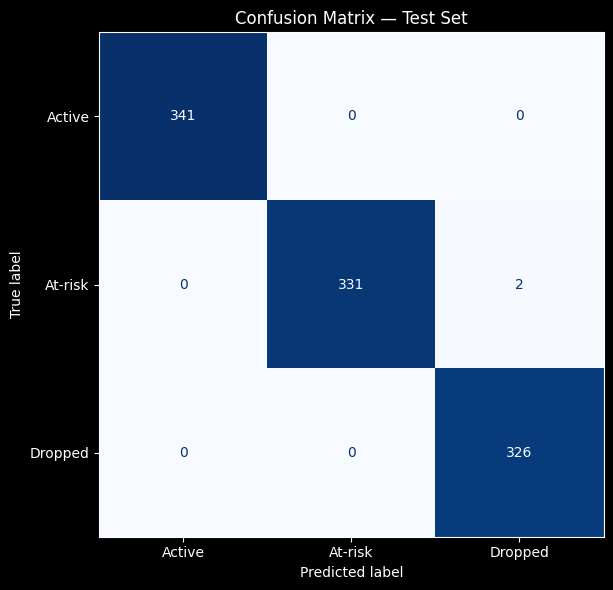

In [20]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)

print("=== Test Set Performance ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Macro : {f1_score(y_test, y_pred, average='macro'):.4f}")
print()
print(classification_report(y_test, y_pred,
      target_names=["Active", "At-risk", "Dropped"]))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["Active", "At-risk", "Dropped"]
)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()

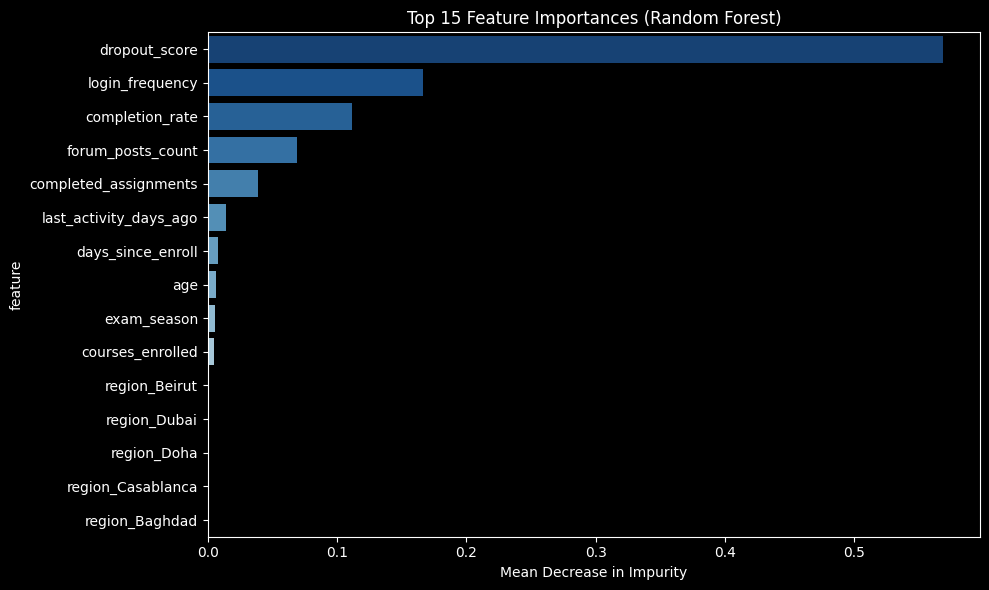

In [22]:
rf_model = best_model.named_steps["classifier"]
preprocessor_fitted = best_model.named_steps["preprocessor"]

# ดึงชื่อ features หลัง transform
cat_feature_names = preprocessor_fitted.named_transformers_["cat"]\
                    .get_feature_names_out(cat_features).tolist()
all_feature_names = num_features + cat_feature_names + bin_features

importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df.head(15), x="importance", y="feature",
            palette="Blues_r")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.show()

Random Forest: Acc=0.9995, F1=0.9995
Gradient Boosting: Acc=0.9998, F1=0.9998
SVM: Acc=0.9617, F1=0.9616


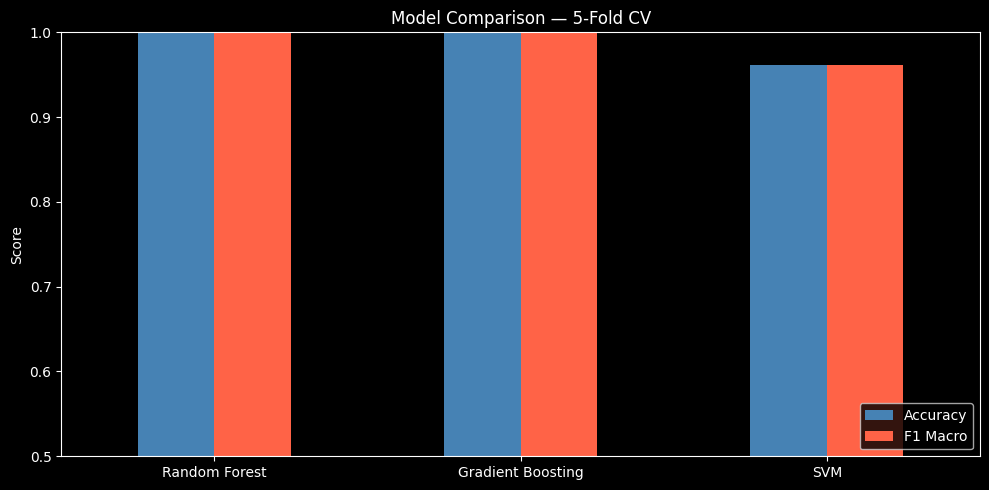

In [24]:
models = {
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            **{k.replace("classifier__", ""): v
               for k, v in grid_search.best_params_.items()},
            random_state=42
        ))
    ]),
    "Gradient Boosting": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", GradientBoostingClassifier(random_state=42))
    ]),
    "SVM": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", SVC(probability=True, random_state=42))
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    cv_res = cross_validate(model, X_train, y_train, cv=cv,
                            scoring=["accuracy", "f1_macro"])
    results[name] = {
        "Accuracy": cv_res["test_accuracy"].mean(),
        "F1 Macro": cv_res["test_f1_macro"].mean(),
    }
    print(f"{name}: Acc={results[name]['Accuracy']:.4f}, "
          f"F1={results[name]['F1 Macro']:.4f}")

results_df = pd.DataFrame(results).T

# Plot เปรียบเทียบ
results_df[["Accuracy", "F1 Macro"]].plot(
    kind="bar", figsize=(10, 5), color=["steelblue", "tomato"])
plt.title("Model Comparison — 5-Fold CV")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0.5, 1.0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [25]:
joblib.dump(best_model, "../models/pipeline.pkl")
print("Model saved to ../models/pipeline.pkl")

# ทดสอบโหลดกลับ
loaded_model = joblib.load("../models/pipeline.pkl")
test_pred = loaded_model.predict(X_test[:3])
print("Test prediction:", test_pred)

Model saved to ../models/pipeline.pkl
Test prediction: [1 2 1]
